In [2]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# %pip install ucimlrepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features
y = wine_quality.data.targets

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=40)
# 3 파이프라인구성  (전처리(스케일링)와 선형회귀를 묶어)
pipeline = Pipeline(steps=[
    ('scaler',StandardScaler()),('model', LinearRegression())
])
pipeline.fit(x_train,y_train)
y_pred = pipeline.predict(x_test)
print(mean_absolute_error(y_test,y_pred), mean_squared_error(y_test, y_pred), r2_score(y_test, y_pred))

print(pipeline.score(x_test,y_test))   # 만든 모델의 결정계수

0.5918557979318982 0.5824131299058521 0.27004856843816005
0.27004856843816005


In [55]:
x = X[['fixed_acidity', 'density']]
y = x[['density']]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=40)
model = LinearRegression()
model.fit(x,y)
s = model.predict(x_test)
r2_score(y_test, s)

1.0

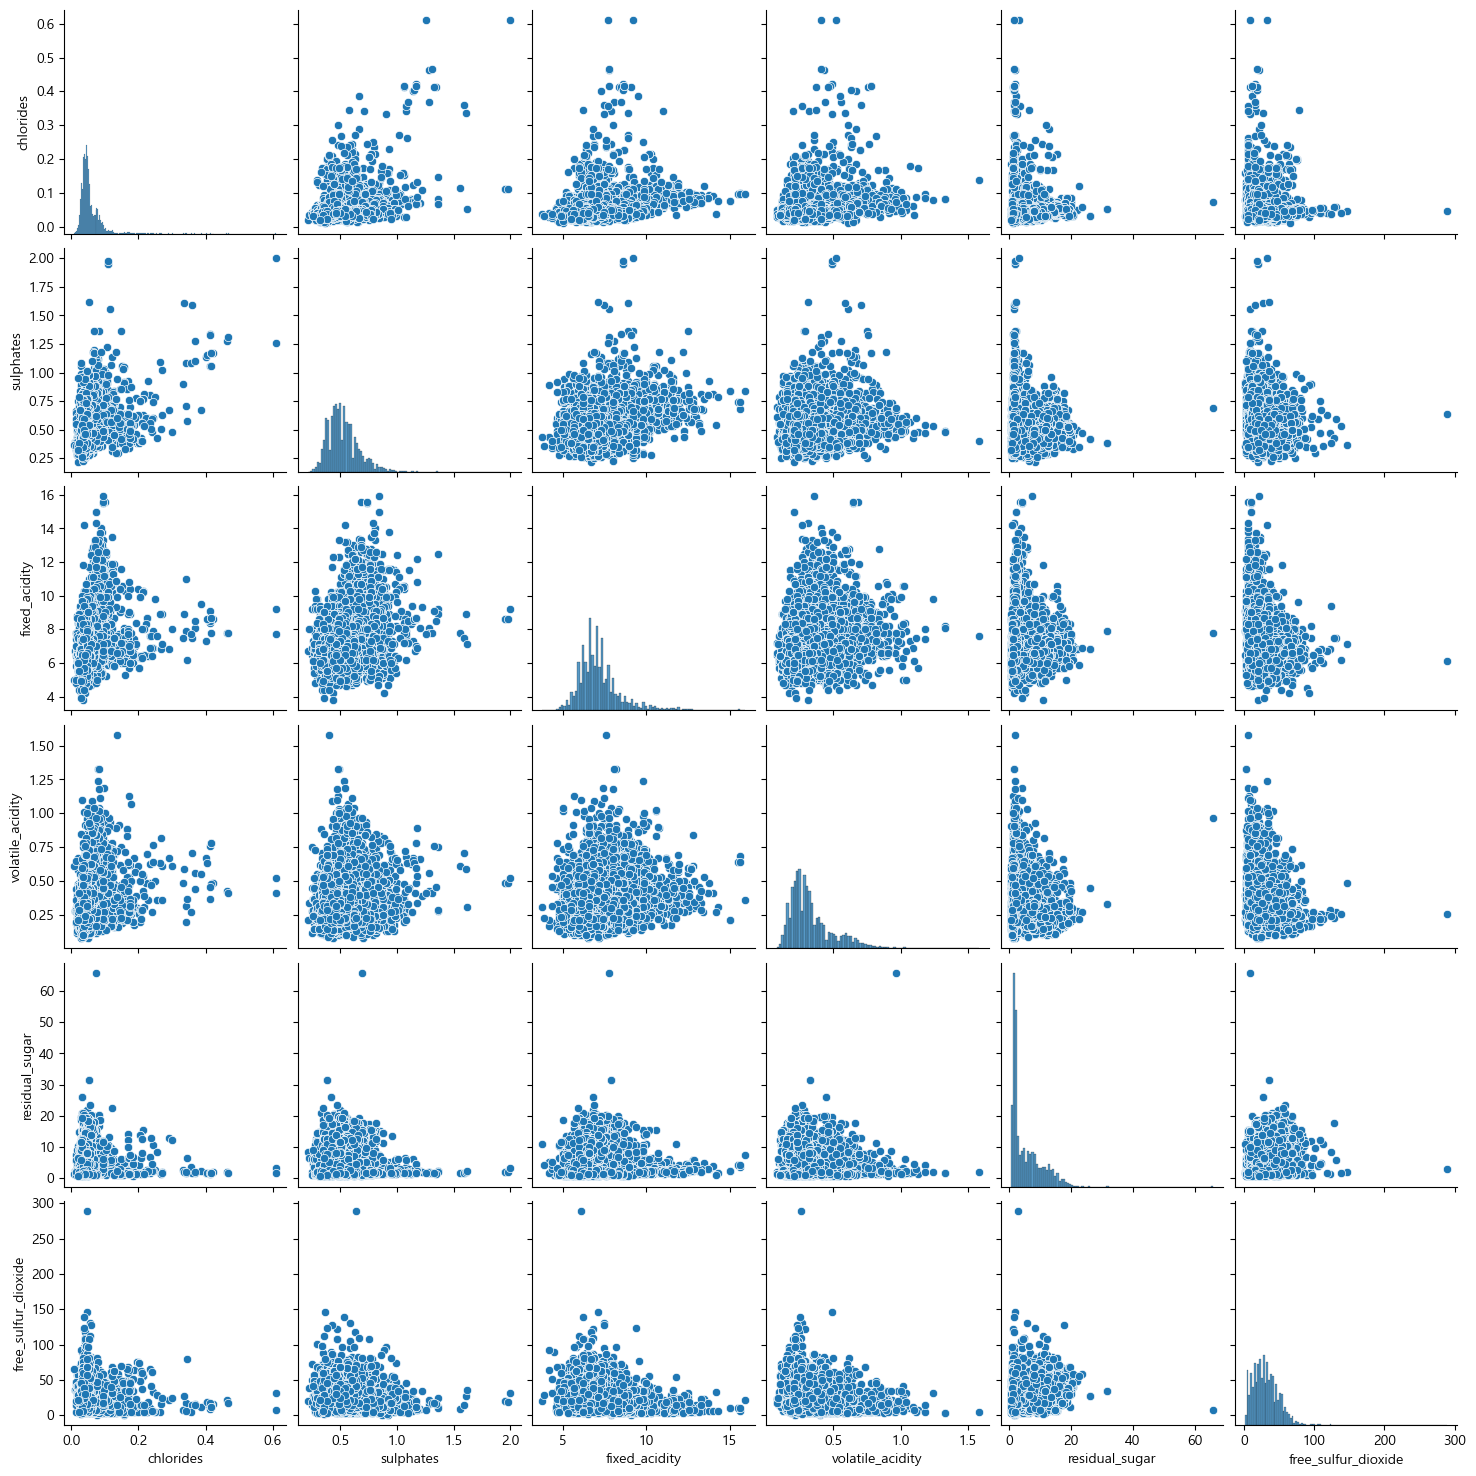

In [63]:
# 왜도 계산 보완
skew_serise = X.skew(numeric_only=True).sort_values(ascending=False)
high_skew_feature = skew_serise[skew_serise > 1].index
sns.pairplot(X[high_skew_feature])